In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json

# Set random seed for reproducibility
np.random.seed(42)

# Generate mock data for weather impact on ice cream sales
def generate_weather_icecream_data(n_days=365):
    """
    Generate mock dataset for studying causal impact of weather on ice cream sales.
    
    Variables:
    - temperature: Daily temperature in Fahrenheit
    - humidity: Relative humidity percentage  
    - weekend: Binary indicator for weekend days
    - holiday: Binary indicator for holidays
    - price: Ice cream price (varies by season)
    - ice_cream_sales: Number of ice cream units sold
    """
    
    # Create date range
    start_date = datetime(2023, 1, 1)
    dates = [start_date + timedelta(days=i) for i in range(n_days)]
    
    # Generate temperature with seasonal pattern + noise
    day_of_year = np.arange(1, n_days + 1)
    seasonal_temp = 65 + 25 * np.sin(2 * np.pi * day_of_year / 365 - np.pi/2)  # Peak in summer
    temperature = seasonal_temp + np.random.normal(0, 8, n_days)
    
    # Generate humidity (negatively correlated with temperature)
    humidity = 60 - 0.3 * (temperature - 65) + np.random.normal(0, 10, n_days)
    humidity = np.clip(humidity, 20, 95)
    
    # Weekend indicator
    weekend = np.array([date.weekday() >= 5 for date in dates]).astype(int)
    
    # Holiday indicator (simplified - major US holidays)
    holidays = [
        datetime(2023, 1, 1),   # New Year
        datetime(2023, 7, 4),   # July 4th
        datetime(2023, 12, 25), # Christmas
    ]
    holiday = np.array([1 if any(abs((date - h).days) < 2 for h in holidays) else 0 for date in dates])
    
    # Price (higher in summer, lower in winter)
    price = 4.0 + 1.5 * np.sin(2 * np.pi * day_of_year / 365 - np.pi/2) + np.random.normal(0, 0.2, n_days)
    price = np.clip(price, 2.5, 6.5)
    
    # Generate ice cream sales with causal relationships
    # Base sales + temperature effect + weekend effect + holiday effect + price effect + noise
    base_sales = 100
    temp_effect = 3.5 * (temperature - 50)  # Strong positive temperature effect
    weekend_effect = 25 * weekend  # Weekend boost
    holiday_effect = 40 * holiday  # Holiday boost
    price_effect = -15 * (price - 4.0)  # Negative price effect
    humidity_effect = -0.5 * (humidity - 60)  # Slight negative humidity effect
    
    ice_cream_sales = (base_sales + temp_effect + weekend_effect + 
                      holiday_effect + price_effect + humidity_effect + 
                      np.random.normal(0, 20, n_days))
    
    # Ensure non-negative sales
    ice_cream_sales = np.maximum(ice_cream_sales, 10)
    
    # Create DataFrame
    df = pd.DataFrame({
        'date': dates,
        'temperature': temperature,
        'humidity': humidity,
        'weekend': weekend,
        'holiday': holiday,
        'price': price,
        'ice_cream_sales': ice_cream_sales
    })
    
    return df

# Generate the dataset
df = generate_weather_icecream_data(365)

# Display basic statistics
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSummary Statistics:")
print(df.describe())

# Save dataset
df.to_csv('.opencode/runs/20251026/weather-icecream-sales/weather_icecream_data.csv', index=False)
print(f"\nDataset saved to: .opencode/runs/20251026/weather-icecream-sales/weather_icecream_data.csv")

Dataset Shape: (365, 7)

First 5 rows:
        date  temperature   humidity  weekend  holiday     price  \
0 2023-01-01    43.977417  62.294570        1        1  2.539391   
1 2023-01-02    38.908701  70.068315        0        1  2.500000   
2 2023-01-03    45.214838  66.061473        0        0  2.583650   
3 2023-01-04    52.243481  64.803717        0        0  2.500000   
4 2023-01-05    38.219319  60.304107        0        0  2.711384   

   ice_cream_sales  
0       163.068474  
1       120.218998  
2        61.502428  
3       146.276879  
4        84.874573  

Summary Statistics:
                      date  temperature    humidity     weekend     holiday  \
count                  365   365.000000  365.000000  365.000000  365.000000   
mean   2023-07-02 00:00:00    65.079571   59.595987    0.287671    0.021918   
min    2023-01-01 00:00:00    25.416257   21.262093    0.000000    0.000000   
25%    2023-04-02 00:00:00    48.304028   51.486126    0.000000    0.000000   
50%    202

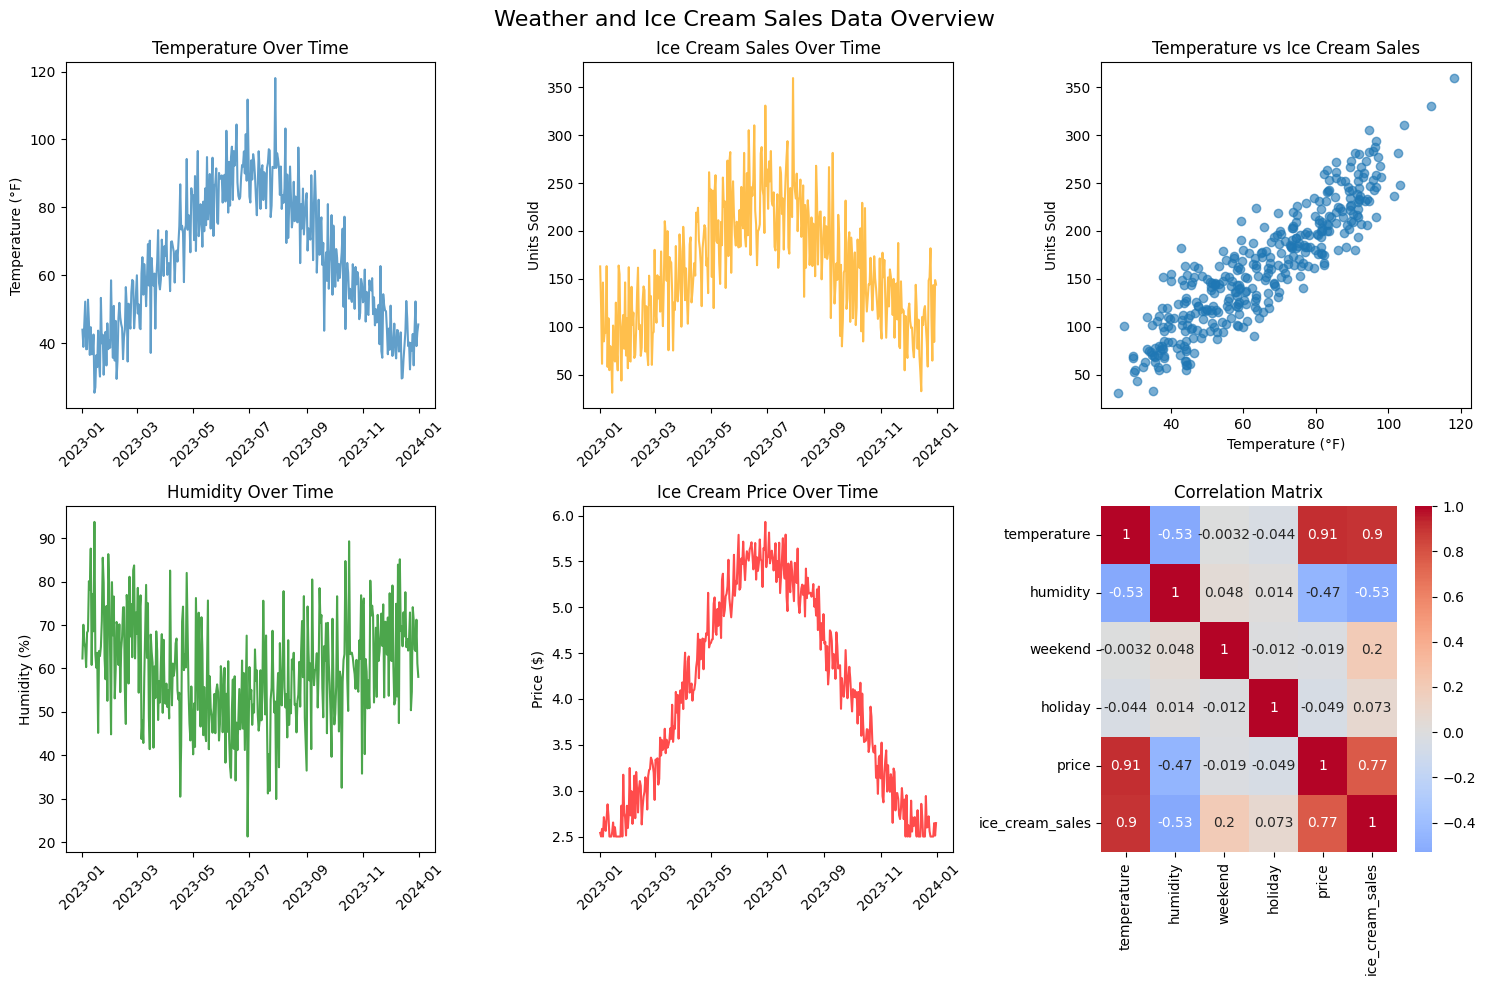

Key Correlations with Ice Cream Sales:
ice_cream_sales    1.000000
temperature        0.901823
price              0.765402
weekend            0.201660
holiday            0.072834
humidity          -0.531172
Name: ice_cream_sales, dtype: float64


In [2]:
# Create visualizations to understand the data
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Weather and Ice Cream Sales Data Overview', fontsize=16)

# Temperature over time
axes[0,0].plot(df['date'], df['temperature'], alpha=0.7)
axes[0,0].set_title('Temperature Over Time')
axes[0,0].set_ylabel('Temperature (°F)')
axes[0,0].tick_params(axis='x', rotation=45)

# Ice cream sales over time
axes[0,1].plot(df['date'], df['ice_cream_sales'], alpha=0.7, color='orange')
axes[0,1].set_title('Ice Cream Sales Over Time')
axes[0,1].set_ylabel('Units Sold')
axes[0,1].tick_params(axis='x', rotation=45)

# Temperature vs Ice Cream Sales scatter
axes[0,2].scatter(df['temperature'], df['ice_cream_sales'], alpha=0.6)
axes[0,2].set_title('Temperature vs Ice Cream Sales')
axes[0,2].set_xlabel('Temperature (°F)')
axes[0,2].set_ylabel('Units Sold')

# Humidity over time
axes[1,0].plot(df['date'], df['humidity'], alpha=0.7, color='green')
axes[1,0].set_title('Humidity Over Time')
axes[1,0].set_ylabel('Humidity (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Price over time
axes[1,1].plot(df['date'], df['price'], alpha=0.7, color='red')
axes[1,1].set_title('Ice Cream Price Over Time')
axes[1,1].set_ylabel('Price ($)')
axes[1,1].tick_params(axis='x', rotation=45)

# Correlation heatmap
correlation_data = df[['temperature', 'humidity', 'weekend', 'holiday', 'price', 'ice_cream_sales']]
correlation_matrix = correlation_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,2])
axes[1,2].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('.opencode/runs/20251026/weather-icecream-sales/data_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# Print key correlations
print("Key Correlations with Ice Cream Sales:")
print(correlation_matrix['ice_cream_sales'].sort_values(ascending=False))